In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def compute_spectra(bins, v, ndft):
    sfdr = np.zeros(len(bins))
    hd3 = np.zeros(len(bins))
    spec_dbv_out = np.zeros((len(bins), ndft//2+1))
    for i in bins:
        y = v[i-1, :]
        y = y[:-1]
        relative_error = (y[-1]-y[-1-ndft])/y[-1]
        print(relative_error)
        y = y[-ndft:]
        spec = np.fft.rfft(y)
        spec_dbv = 20*np.log10(np.abs(spec)/(ndft/2))
        spec_dbv_out[i-1, :] = spec_dbv
        sfdr[i-1] = spec_dbv[i] - np.max(np.delete(spec_dbv, [0, i]))
        hd3[i-1] = spec_dbv[i] - spec_dbv[get_third_harmonic_bin(i, ndft)]
    return sfdr, hd3, spec_dbv_out

In [3]:
def get_third_harmonic_bin(i, ndft):
    """
    Finds the 3rd harmonic bin for a real-valued signal.
    i: fundamental bin index
    nfft: total number of FFT points
    """
    # Step 1: Wrap around the sampling frequency
    wrapped_bin = (3 * i) % ndft
    
    # Step 2: Fold back if it's above Nyquist
    if wrapped_bin > ndft // 2:
        harmonic_bin = ndft - wrapped_bin
    else:
        harmonic_bin = wrapped_bin
        
    return int(harmonic_bin)

In [4]:
df1 = pd.read_csv('./xschem/simulation/tb_boot_bottom_2.txt', sep='\\s+')
df1

,time,v(vi),v(vo)
0,1.900000e-09,0.657404,0.633103
1,3.900000e-09,0.715502,0.692412
2,5.900000e-09,0.768872,0.747947
3,7.900000e-09,0.815329,0.797436
4,9.900000e-09,0.852970,0.838848
...,...,...,...
535,6.390000e-08,0.675265,0.897151
536,6.590000e-08,0.495741,0.301498
537,6.790000e-08,0.732182,0.896099
538,6.990000e-08,0.441251,0.308117


In [5]:
# Parameters
fs = 500e6
ndft = 31
runs = 15
bins = np.arange(1, runs+1)

In [6]:
vi = np.reshape(df1['v(vi)'].values, [runs, len(df1)//runs])
vo = np.reshape(df1['v(vo)'].values, [runs, len(df1)//runs])

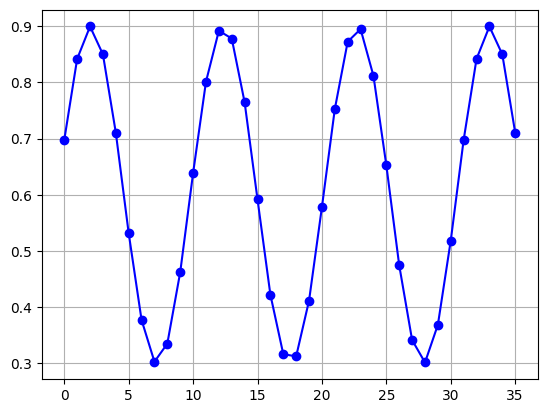

In [7]:
plt.plot(vo[2, :], "b-o")
plt.grid()
plt.show()

In [8]:
hd3_vi = compute_spectra(bins, vi, ndft)[1]
hd3_vo = compute_spectra(bins, vo, ndft)[1]

-1.2264991829370614e-10
4.011727995567641e-08
3.739477954159217e-09
7.0472249034468425e-09
-1.082199738517768e-07
-1.1465745090517788e-06
7.962172982259036e-07
-2.2676037934042847e-07
4.354903840926782e-07
1.7253974006169124e-06
6.0730806734922264e-09
-3.1156211796501468e-09
-2.456421134787704e-06
-8.518860376606383e-06
7.890300803377077e-06
5.553643437265203e-06
-2.5527816693250792e-06
-3.867296143921045e-06
-2.1971212115205014e-06
3.515075610028222e-06
-1.7974840859541154e-06
2.978479648854135e-08
-1.1143300882838804e-05
1.7223543054192456e-05
3.8170307721608024e-05
6.619738793922029e-07
2.424584804252711e-07
1.4464526180716178e-05
9.270931012175922e-06
6.479024180082477e-06


In [9]:
# Analytical data
vov = 0.734
vm = 0.3
fs = 500e6
fin = bins*fs/ndft
c = 1.3e-12
cb = 1e-12
cp =  50e-15
fbw = 4.9e9
hd3_calc = -20*np.log10((1/2)*fin/fbw*(vm/vov)**2 *(cp/cb+0.1)**2)
print(fbw/1e6)

4900.0


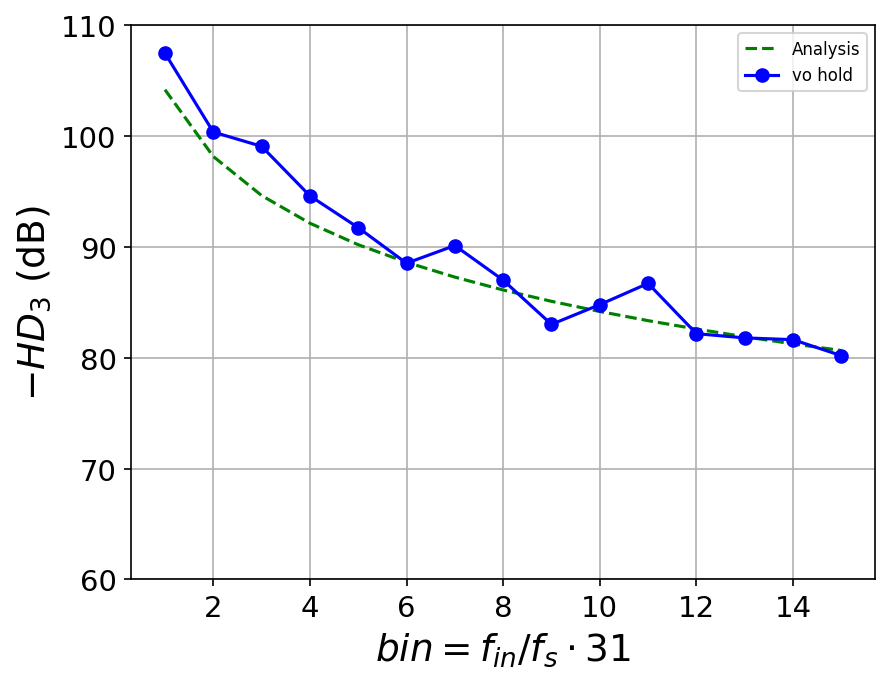

In [10]:
plt.rcParams['figure.dpi'] = 150
plt.plot(bins, hd3_calc, "g--", label='Analysis')
#plt.plot(bins, hd3_vi, "r--", label='vi hold')
plt.plot(bins, hd3_vo, "b-o", label='vo hold')
    
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("$-HD_3$ (dB)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(60, 110)
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

5.553643437265203e-06
-2.5527816693250792e-06
-3.867296143921045e-06
-2.1971212115205014e-06
3.515075610028222e-06
-1.7974840859541154e-06
2.978479648854135e-08
-1.1143300882838804e-05
1.7223543054192456e-05
3.8170307721608024e-05
6.619738793922029e-07
2.424584804252711e-07
1.4464526180716178e-05
9.270931012175922e-06
6.479024180082477e-06


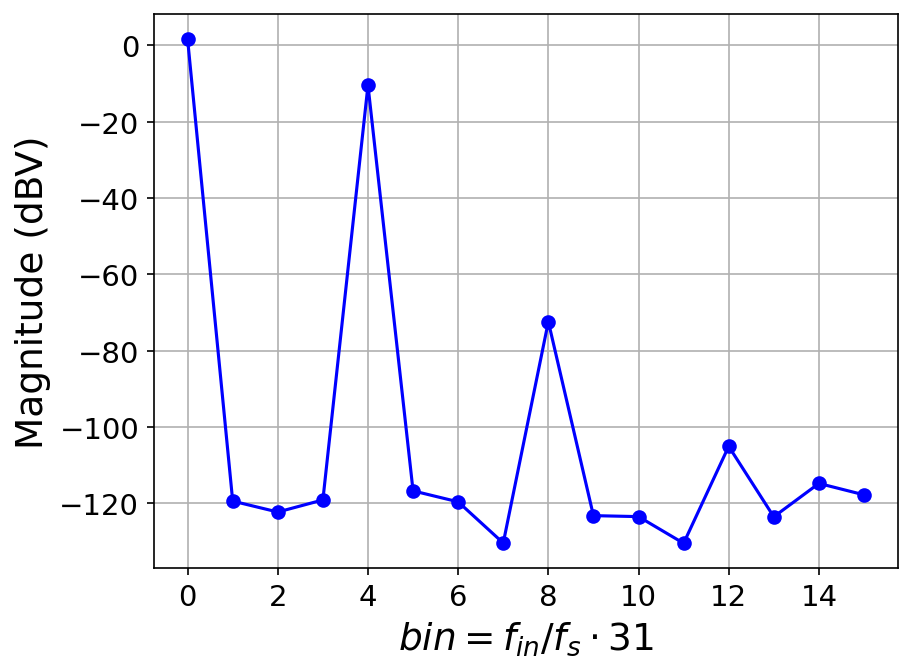

In [11]:
spec_dbv_out = compute_spectra(bins, vo, ndft)[2]

plt.plot(spec_dbv_out[3, :], "b-o")
plt.grid()
plt.xlabel("$bin = f_{in}/f_s \\cdot 31$", fontsize=18)
plt.ylabel("Magnitude (dBV)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.ylim(25, 72)
plt.grid(True)
plt.show()
